In [1]:
from src.fxlms import FxLMS
import soundfile as sf
import numpy as np
from scipy.io import loadmat

In [2]:
ir = loadmat('data/panel_ir_clean.mat')
panel_ir = ir['panel_ir'].squeeze()
panel_ir.shape

(128,)

In [3]:
wav, sr = sf.read('audio_experiments/mics_nc.wav')
wav.shape

(240640, 2)

In [4]:
target = wav[:, 0]
ref = wav[:, 1]

ref.shape, target.shape

((240640,), (240640,))

Final MSE: 1.593e-08
Lowest MSE: 1.593e-08


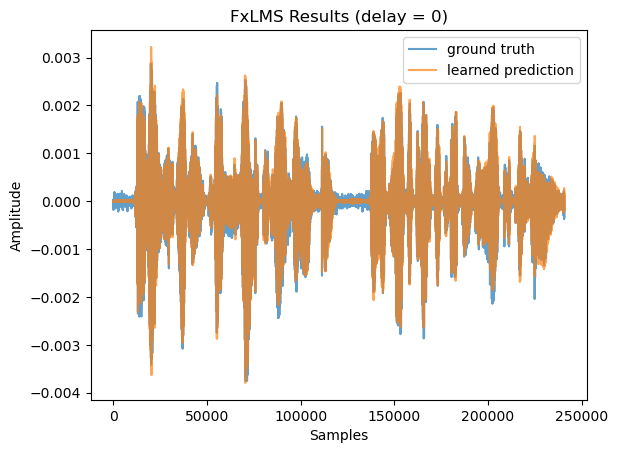

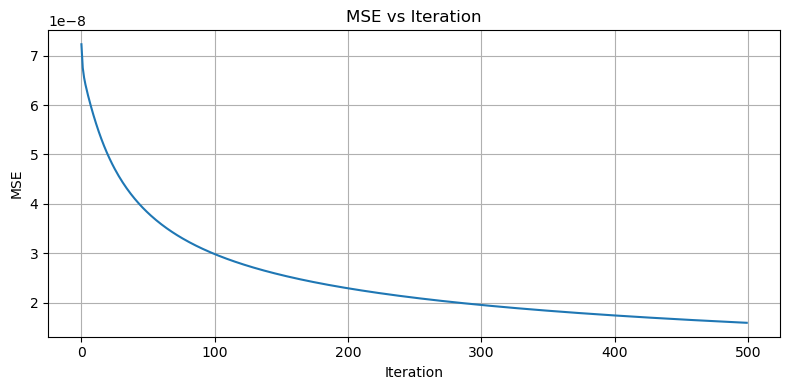

In [7]:
step_fn = lambda t: 1e-2 / np.sqrt(1 + t / 20)
fx = FxLMS(ref, target, panel_ir, filter_order=1024, step_fn=step_fn, delay=0)
fx.learn(n_iter = 500)

Final MSE: 2.334e-07
Lowest MSE: 2.334e-07


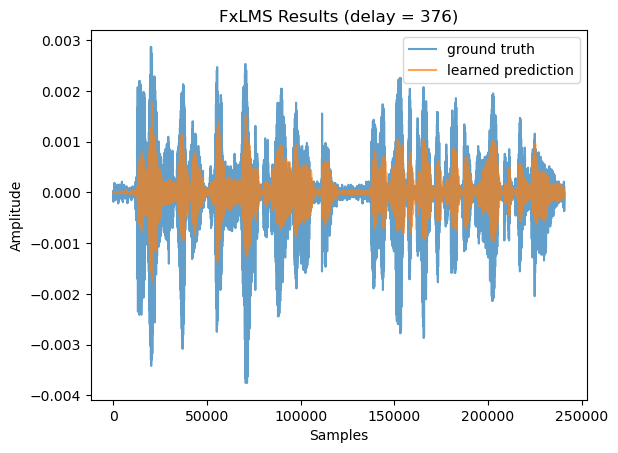

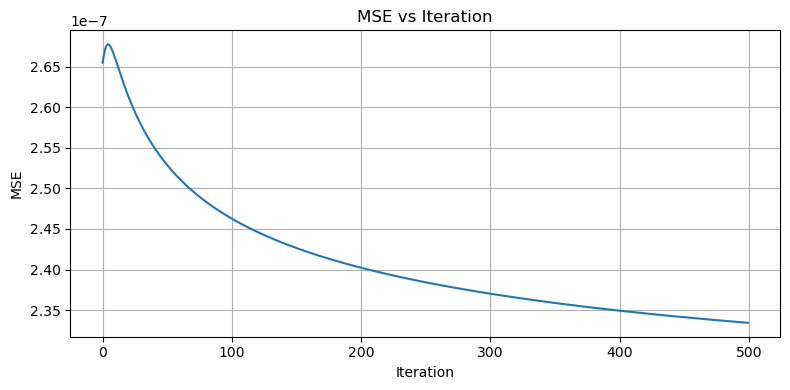

In [9]:
fx = FxLMS(ref, target, panel_ir, filter_order=1024, step_fn=step_fn, delay=376)
fx.learn(n_iter = 500)

Final MSE: 1.593e-08
Lowest MSE: 1.593e-08


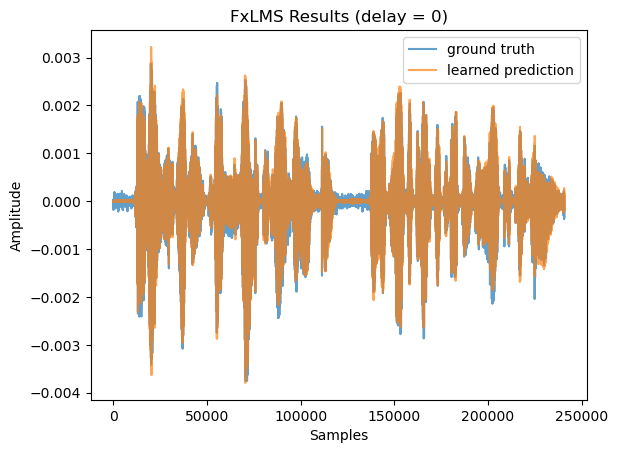

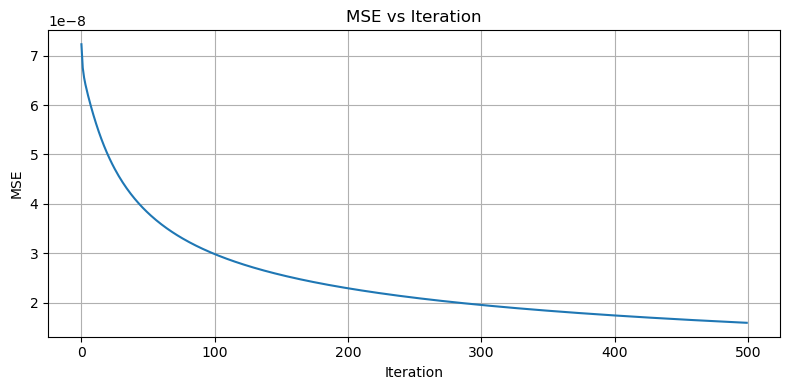

Final MSE: 2.085e-07
Lowest MSE: 2.085e-07


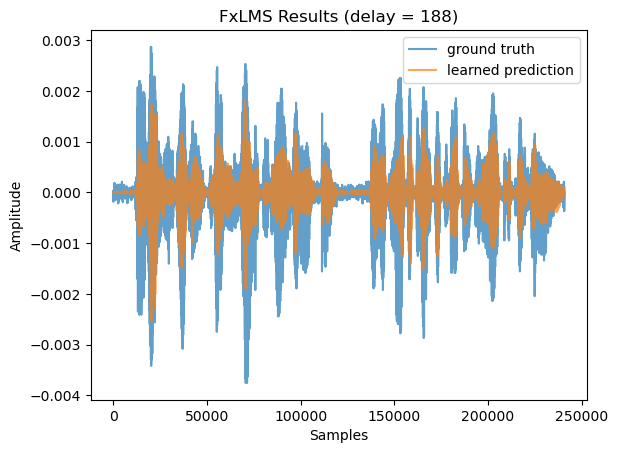

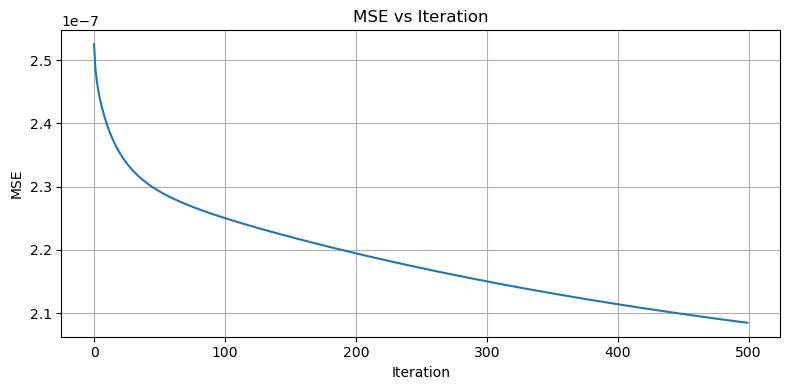

Final MSE: 2.334e-07
Lowest MSE: 2.334e-07


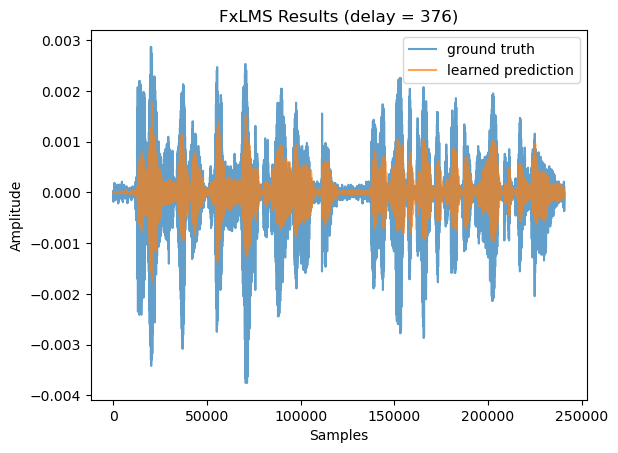

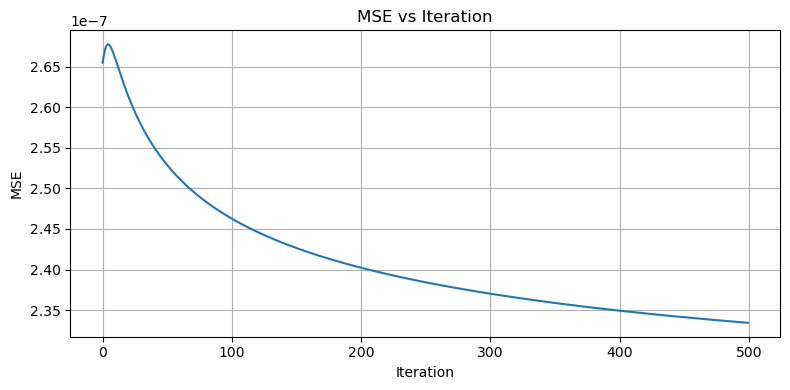

Final MSE: 2.820e-07
Lowest MSE: 2.820e-07


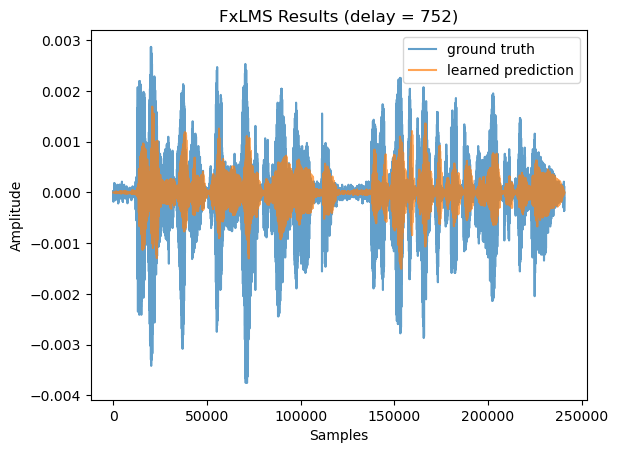

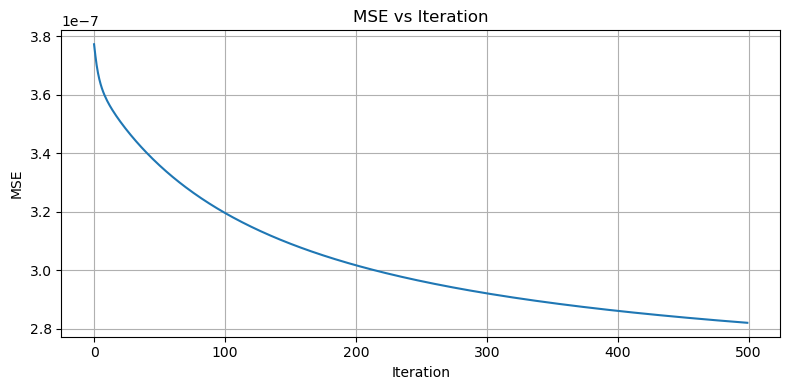

Final MSE: 2.860e-07
Lowest MSE: 2.857e-07


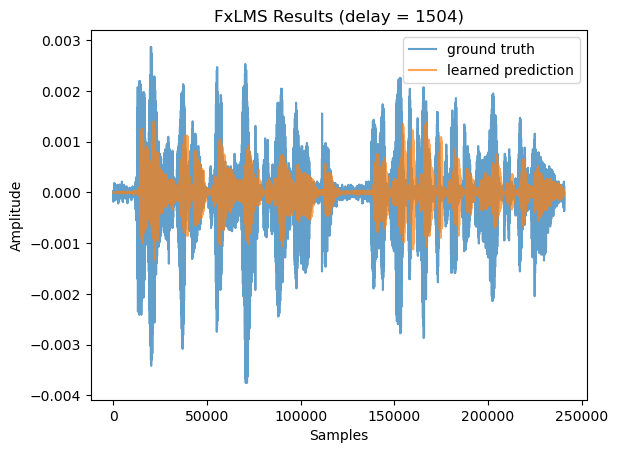

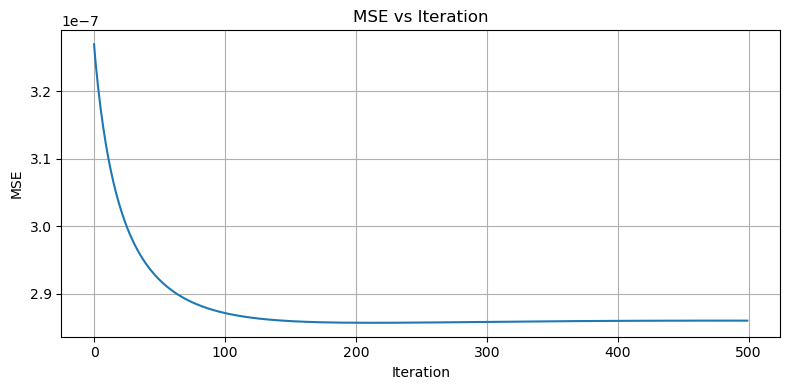

Final MSE: 3.052e-07
Lowest MSE: 3.052e-07


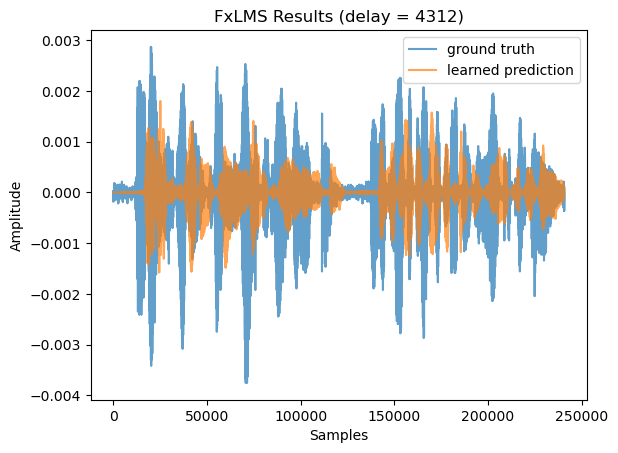

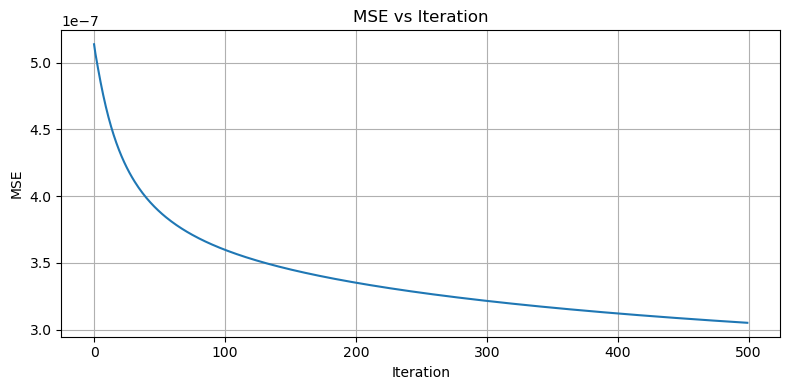

In [15]:
step_fn = lambda t: 1e-2 / np.sqrt(1 + t / 20)
db_reductions = []
mses = []
delays = [0, 188, 376, 752, 1504, 4312]

for delay in delays:
    fx = FxLMS(ref, target, panel_ir, filter_order=1024, step_fn=step_fn, delay=delay)
    fx.learn(n_iter = 500)
    db_reductions.append(fx.db_reductions[-1])
    mses.append(fx.mses[-1])

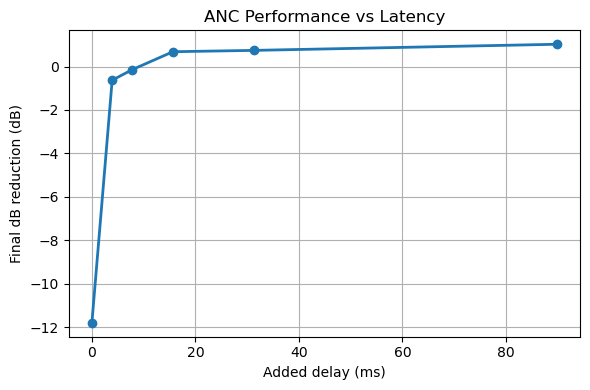

In [22]:
import matplotlib.pyplot as plt

fs = 48000
delay_ms = [1000 * d / fs for d in delays]

plt.figure(figsize=(6,4))
plt.plot(delay_ms, db_reductions, marker='o', linewidth=2)

plt.xlabel("Added delay (ms)")
plt.ylabel("Final dB reduction (dB)")
plt.title("ANC Performance vs Latency")
plt.grid(True)


plt.tight_layout()
plt.show()

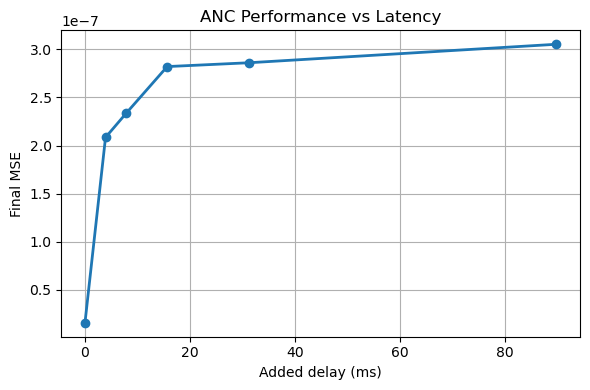

In [18]:
plt.figure(figsize=(6,4))
plt.plot(delay_ms, mses, marker='o', linewidth=2)

plt.xlabel("Added delay (ms)")
plt.ylabel("Final MSE")
plt.title("ANC Performance vs Latency")
plt.grid(True)


plt.tight_layout()
plt.show()